In [52]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')
from src.pipeline import Preprocessor, Segmentation, FeatureExtraction
import cv2 
import os 
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
def print_img(img) -> None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.show()

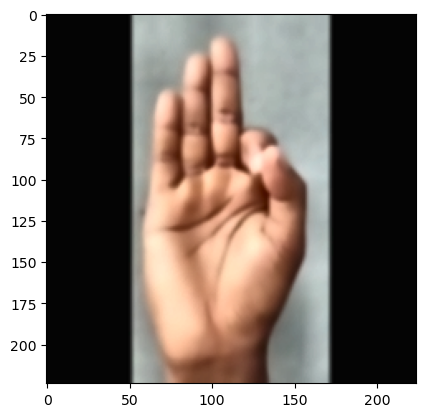

In [54]:
path = "../sample_data/P1_F_68.jpg"
img = cv2.imread(path)
preprocessor = Preprocessor()
img = preprocessor.resize(img)
img = preprocessor.gamma_correction(img)
img = preprocessor.bilateral_filter(img)
img = preprocessor.gaussian_blur(img)
img = preprocessor.clahe_enhancement(img)
print_img(img)

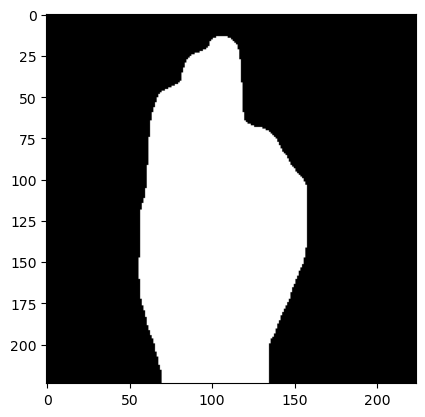

In [55]:
segmentor = Segmentation()
mask = segmentor.hsv_mask(img)
mask = segmentor.refine_mask(mask)
print_img(mask)


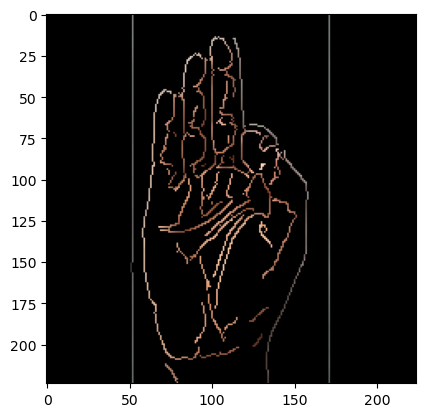

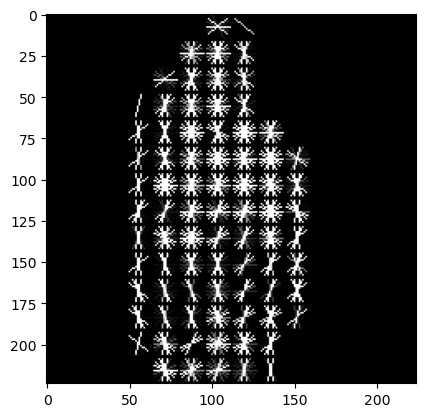

In [57]:
feat_extract = FeatureExtraction()
feats = feat_extract.extract_canny_edges(img)
print_img(feats)
feats = feat_extract.compute_hog(img, mask=mask)
print_img(feats)